In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as pl
import numpy as np
import os
import pandas as pd
from tensorflow.keras import layers

2025-05-19 01:05:15.854224: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-19 01:05:15.864221: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-19 01:05:15.935736: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-19 01:05:15.996943: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747596916.063673   22054 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747596916.08

In [2]:
base_dir = "./Dataset"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

In [3]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
SEED = 42  # For reproducible shuffling/splitting

# ======================
# 3. Load Raw Datasets
initial_load = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED
)
class_names = initial_load.class_names
print("Class names:", class_names)

# 4. Proper dataset loading with all transformations
def create_dataset(subset=None, shuffle=True):
    return image_dataset_from_directory(
        train_dir if subset else test_dir,
        validation_split=0.2 if subset else None,
        subset=subset,
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        shuffle=shuffle
    ).map(lambda x, y: (x/255.0, y))  # Normalize here

train_dataset = create_dataset("training")
val_dataset = create_dataset("validation")
test_dataset = create_dataset(shuffle=False)  # No subset for test data



Found 34277 files belonging to 5 classes.
Using 27422 files for training.


2025-05-19 01:05:27.656243: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Class names: ['Bio-degradable', 'Electronic', 'Medical', 'Non-degradable', 'Recyclable']
Found 34277 files belonging to 5 classes.
Using 27422 files for training.
Found 34277 files belonging to 5 classes.
Using 6855 files for validation.
Found 8673 files belonging to 5 classes.


Training set distribution:


2025-05-19 01:05:59.607733: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


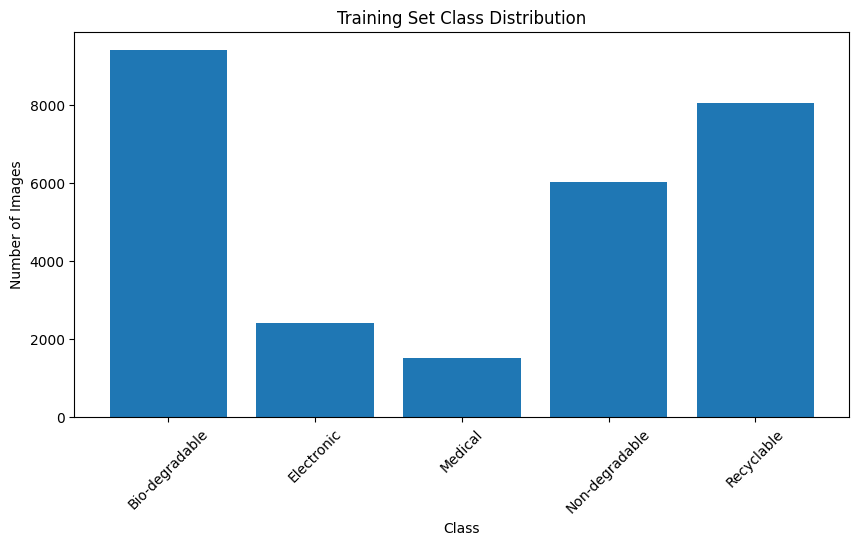

Validation set distribution:


2025-05-19 01:06:08.762138: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


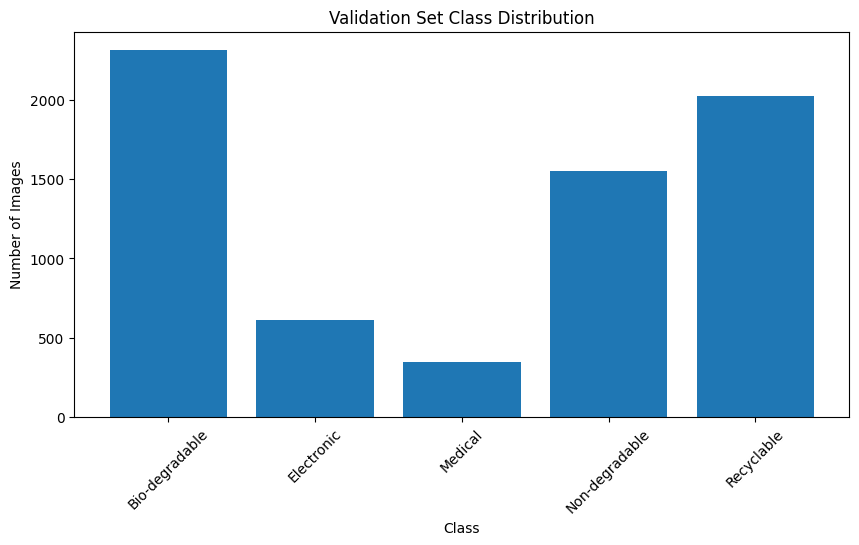

Test set distribution:


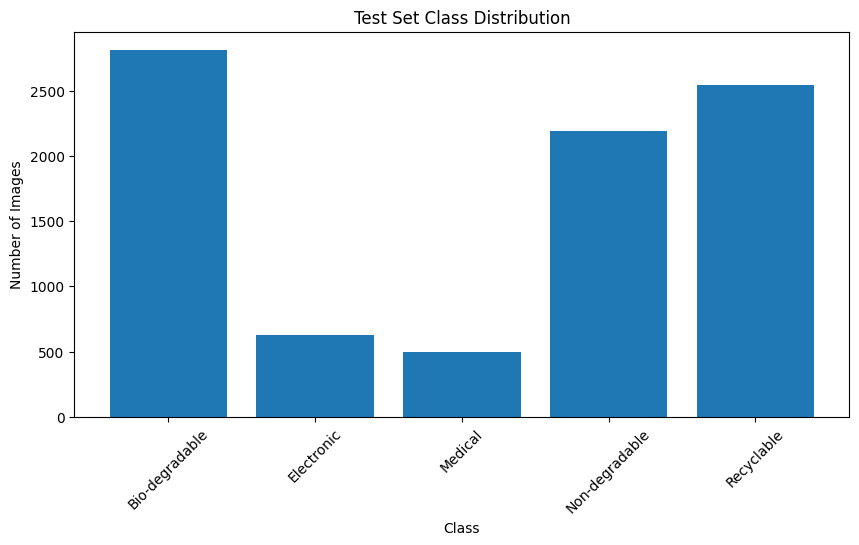

In [4]:
import matplotlib.pyplot as plt

def plot_class_distribution(dataset, title):
    class_counts = {class_name: 0 for class_name in class_names}
    for _, labels in dataset:
        for batch_labels in labels:
            class_idx = tf.argmax(batch_labels).numpy()
            class_counts[class_names[class_idx]] += 1
    
    plt.figure(figsize=(10, 5))
    plt.bar(class_counts.keys(), class_counts.values())
    plt.title(title)
    plt.xlabel('Class')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45)
    plt.show()
    
    return class_counts

# Plot distributions
print("Training set distribution:")
train_counts = plot_class_distribution(train_dataset, "Training Set Class Distribution")

print("Validation set distribution:")
val_counts = plot_class_distribution(val_dataset, "Validation Set Class Distribution")

print("Test set distribution:")
test_counts = plot_class_distribution(test_dataset, "Test Set Class Distribution")

In [5]:
from tensorflow.keras.layers import Resizing, Rescaling
from tensorflow.keras import Sequential

# Define the correct preprocessing pipeline
def build_preprocessing_pipeline(target_size=(224, 224)):
    """
    Creates a preprocessing pipeline with the correct operation order:
    1. Resizing to target dimensions
    2. Normalization (rescaling)
    3. Data augmentation
    """
    preprocessing = Sequential([
        # 1. Resize all images to consistent shape
        Resizing(*target_size),
        
        # 2. Normalize pixel values to [0,1] or [-1,1] (choose one approach)
        # Option A: Scale to [0,1] (simpler)
        Rescaling(1./255),
        
        # Option B: Scale to [-1,1] (better for some pretrained models)
        # Rescaling(1./127.5, offset=-1),
    ])
    return preprocessing

# Create separate augmentation pipeline
def build_augmentation_pipeline():
    """Creates data augmentation pipeline"""
    return Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),
        layers.RandomContrast(0.1),
        layers.RandomTranslation(0.1, 0.1),
    ])

# Build both pipelines
preprocessing = build_preprocessing_pipeline()
augmentation = build_augmentation_pipeline()

In [6]:
def create_enhanced_dataset(subset=None, shuffle=True, augment=False):
    """
    Creates dataset with proper preprocessing pipeline
    """
    # Load raw dataset
    ds = image_dataset_from_directory(
        train_dir if subset else test_dir,
        validation_split=0.2 if subset else None,
        subset=subset,
        seed=SEED,
        image_size=IMG_SIZE,  # Initial loading size (can be different from target size)
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        shuffle=shuffle
    )
    
    # Apply preprocessing
    ds = ds.map(lambda x, y: (preprocessing(x), y),
                num_parallel_calls=tf.data.AUTOTUNE)
    
    # Apply augmentation only to training set
    if augment:
        ds = ds.map(lambda x, y: (augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    
    # Optimize pipeline
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

# Create datasets with proper preprocessing
train_dataset = create_enhanced_dataset("training", augment=True)
val_dataset = create_enhanced_dataset("validation")
test_dataset = create_enhanced_dataset(shuffle=False)

Found 34277 files belonging to 5 classes.
Using 27422 files for training.
Found 34277 files belonging to 5 classes.
Using 6855 files for validation.
Found 8673 files belonging to 5 classes.


Training samples (with augmentation):


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.6844094..1.0096205].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.061287202..1.0002909].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0326927].
2025-05-19 01:06:32.653743: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


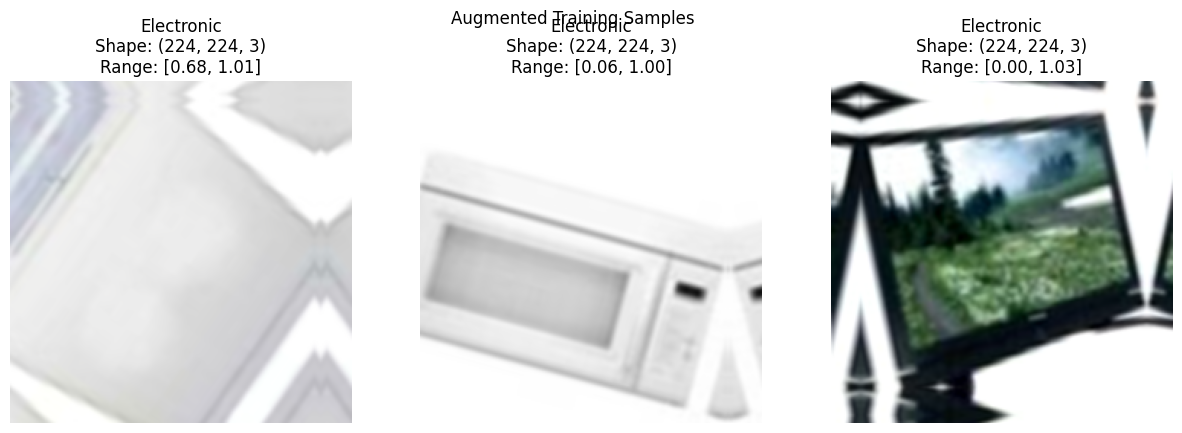

Validation samples (no augmentation):


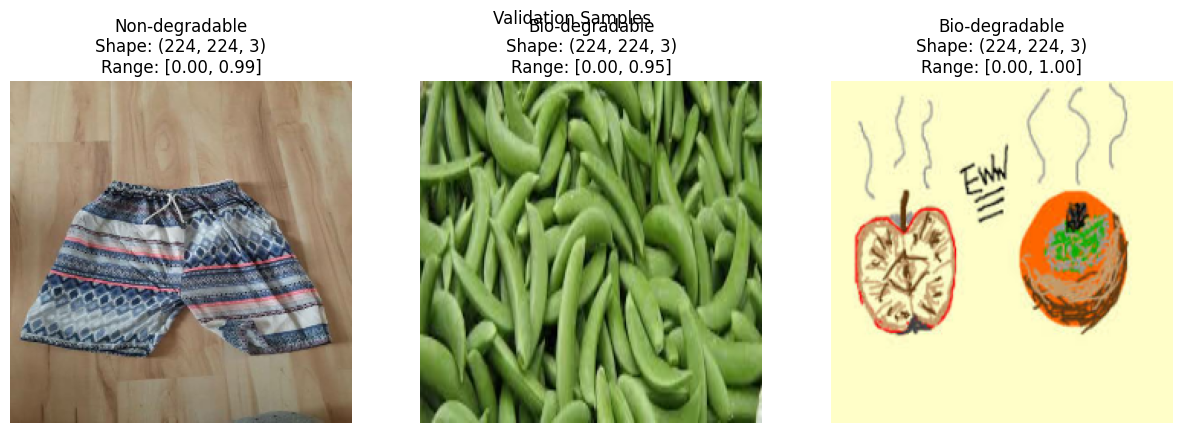

Test samples:


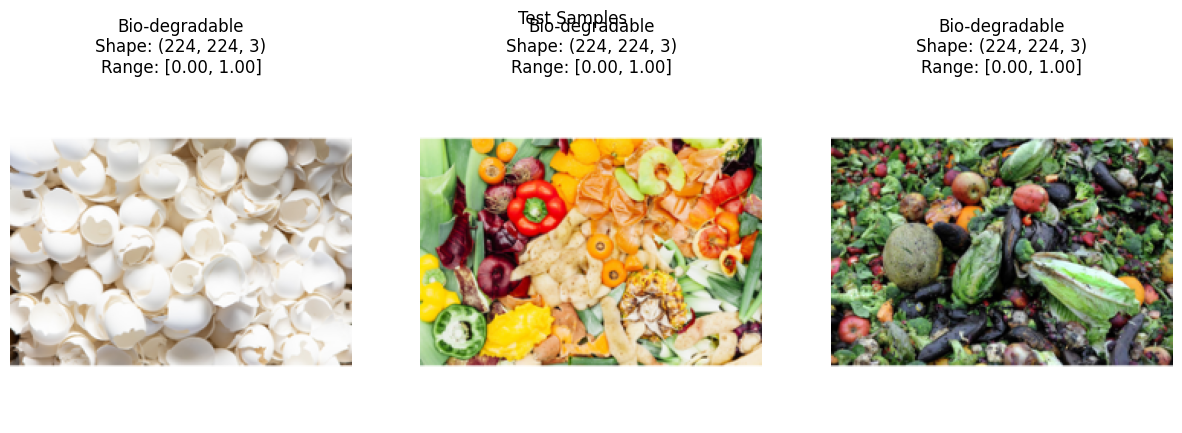

In [7]:
def visualize_preprocessing(dataset, title, samples=3):
    plt.figure(figsize=(15, 5))
    for images, labels in dataset.take(1):
        for i in range(samples):
            ax = plt.subplot(1, samples, i+1)
            plt.imshow(images[i].numpy())
            plt.title(f"{class_names[tf.argmax(labels[i])]}\n"
                     f"Shape: {images[i].shape}\n"
                     f"Range: [{images[i].numpy().min():.2f}, {images[i].numpy().max():.2f}]")
            plt.axis("off")
    plt.suptitle(title)
    plt.show()

# Visualize different stages
print("Training samples (with augmentation):")
visualize_preprocessing(train_dataset, "Augmented Training Samples")

print("Validation samples (no augmentation):")
visualize_preprocessing(val_dataset, "Validation Samples")

print("Test samples:")
visualize_preprocessing(test_dataset, "Test Samples")


Training Set Visualization:


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0160859].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0213063].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0232042].


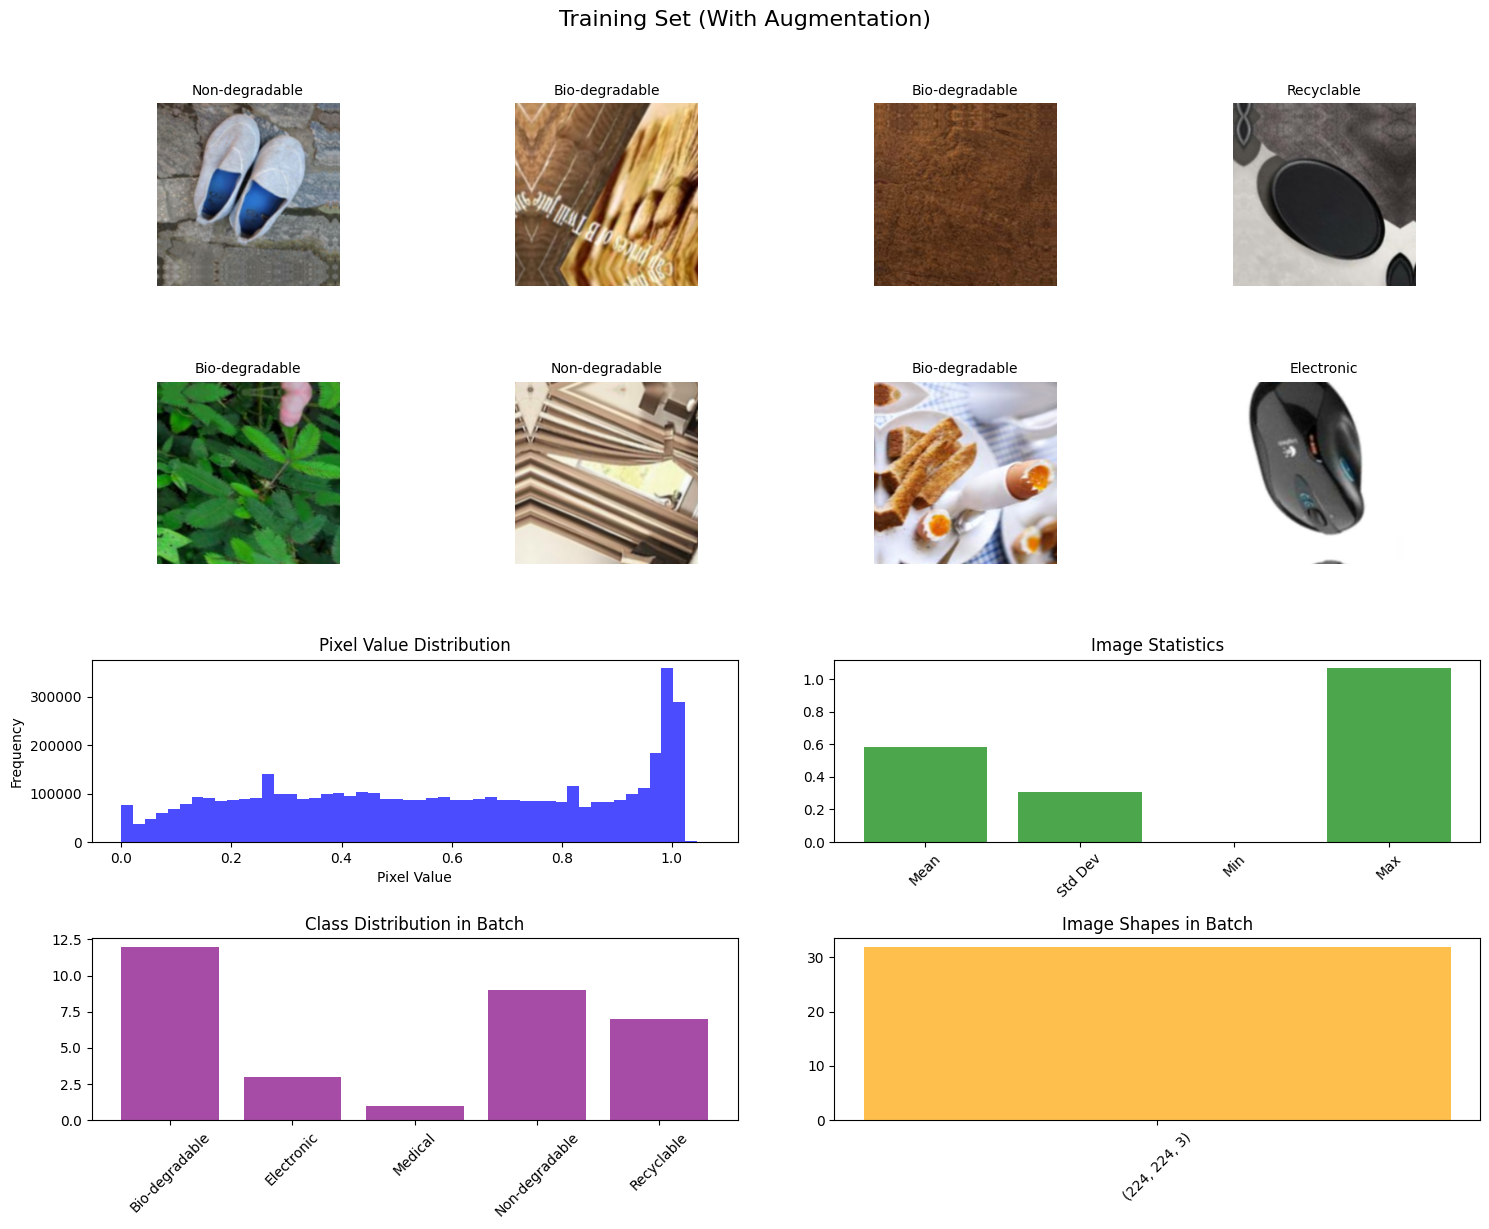


Validation Set Visualization:


2025-05-19 01:06:40.029978: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


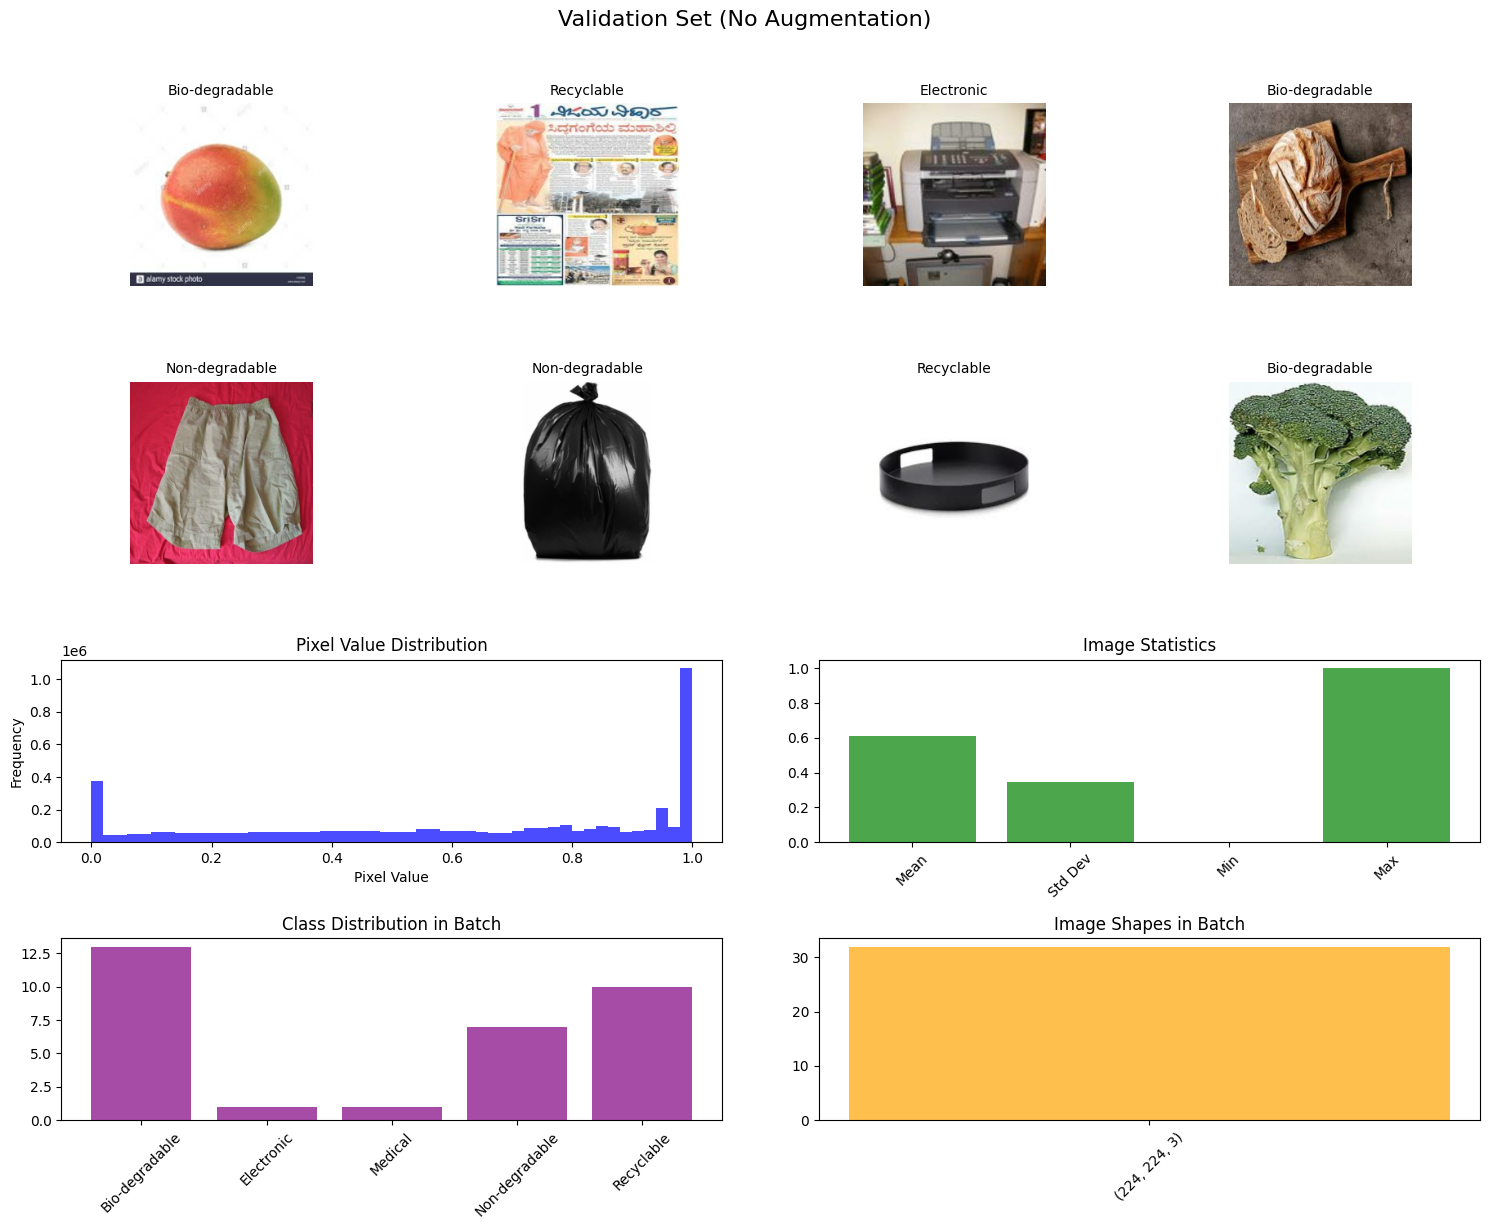


Test Set Visualization:


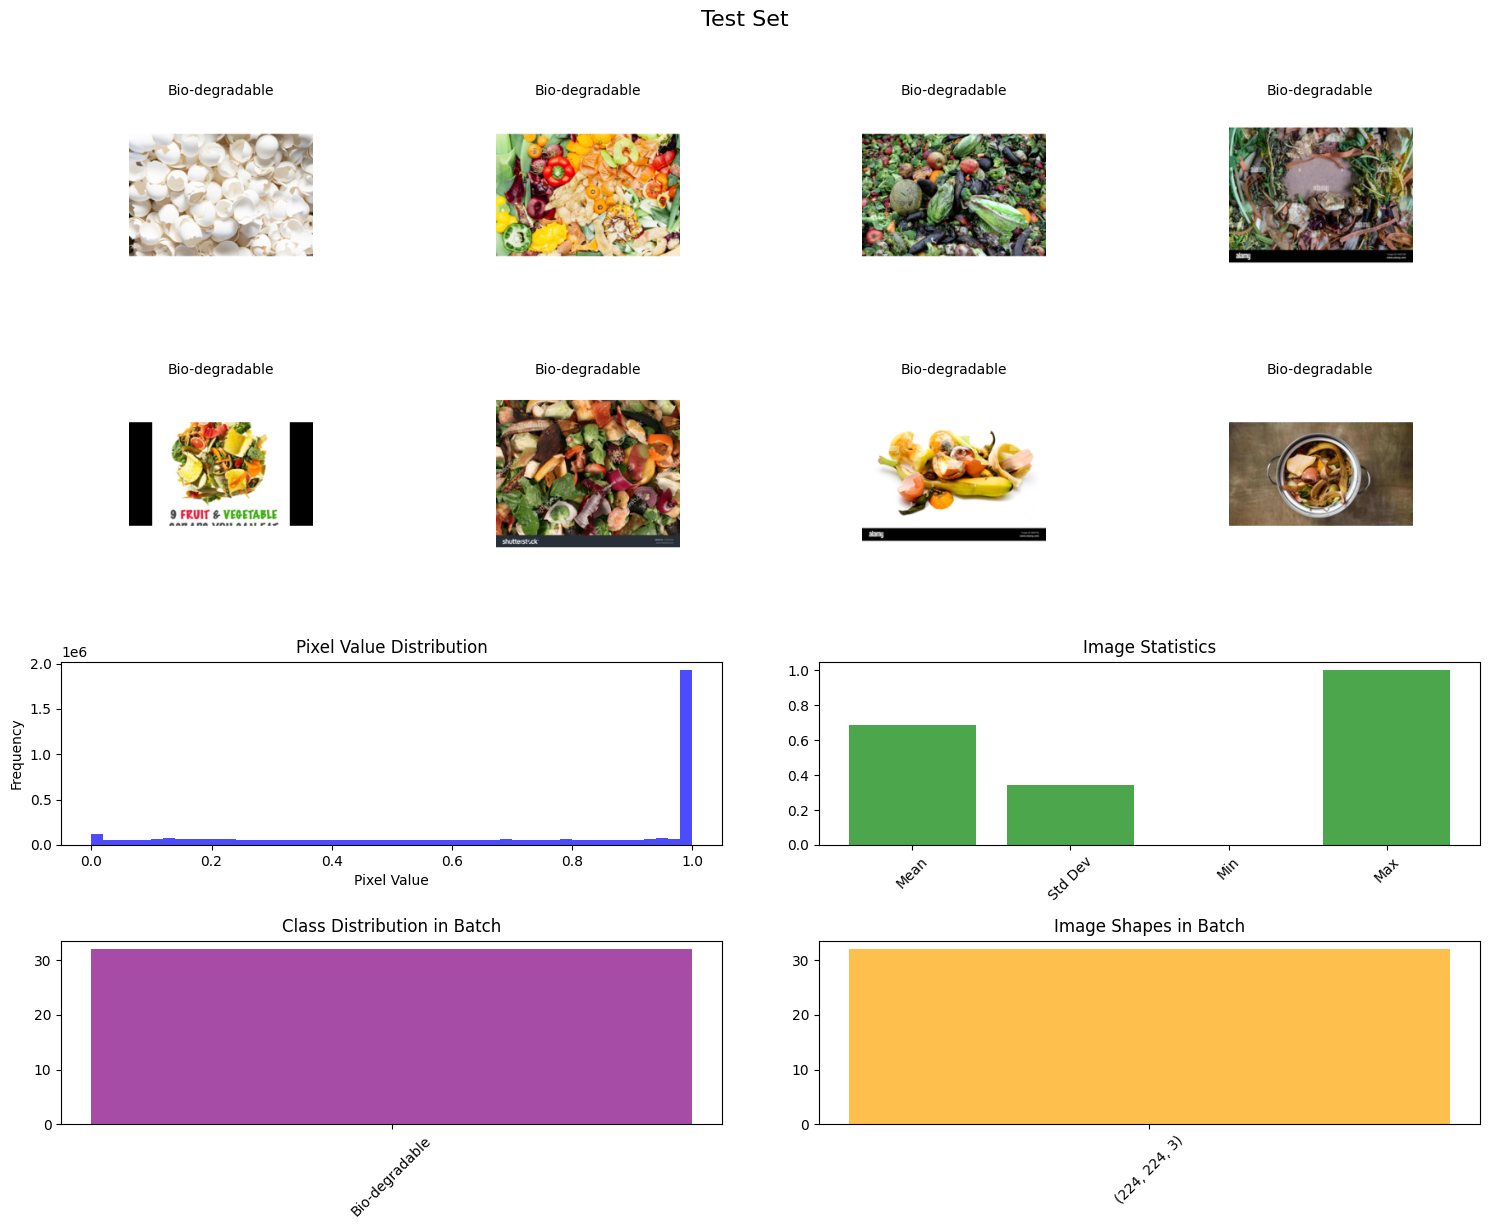

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_dataset(dataset, title, samples=8):
    plt.figure(figsize=(15, 12))
    plt.suptitle(title, y=1.02, fontsize=16)
    
    # Get one batch
    for images, labels in dataset.take(1):
        # Display sample images
        for i in range(samples):
            ax = plt.subplot(4, samples//2, i+1)
            plt.imshow(images[i].numpy())
            plt.title(class_names[np.argmax(labels[i])], fontsize=10)
            plt.axis("off")
        
        # Show pixel value distribution
        plt.subplot(4, 2, 5)
        plt.hist(images.numpy().ravel(), bins=50, color='blue', alpha=0.7)
        plt.title("Pixel Value Distribution")
        plt.xlabel("Pixel Value")
        plt.ylabel("Frequency")
        
        # Show image statistics
        plt.subplot(4, 2, 6)
        stats = {
            'Mean': np.mean(images.numpy()),
            'Std Dev': np.std(images.numpy()),
            'Min': np.min(images.numpy()),
            'Max': np.max(images.numpy())
        }
        plt.bar(stats.keys(), stats.values(), color='green', alpha=0.7)
        plt.title("Image Statistics")
        plt.xticks(rotation=45)
        
        # Show class distribution in this batch
        plt.subplot(4, 2, 7)
        batch_classes = [class_names[np.argmax(label)] for label in labels.numpy()]
        unique, counts = np.unique(batch_classes, return_counts=True)
        plt.bar(unique, counts, color='purple', alpha=0.7)
        plt.title("Class Distribution in Batch")
        plt.xticks(rotation=45)
        
        # Show image sizes
        plt.subplot(4, 2, 8)
        shapes = [str(image.shape) for image in images.numpy()]
        unique_shapes, shape_counts = np.unique(shapes, return_counts=True)
        plt.bar(unique_shapes, shape_counts, color='orange', alpha=0.7)
        plt.title("Image Shapes in Batch")
        plt.xticks(rotation=45)
        
    plt.tight_layout()
    plt.show()

# Visualize all datasets
print("\nTraining Set Visualization:")
visualize_dataset(train_dataset, "Training Set (With Augmentation)")

print("\nValidation Set Visualization:")
visualize_dataset(val_dataset, "Validation Set (No Augmentation)")

print("\nTest Set Visualization:")
visualize_dataset(test_dataset, "Test Set")

In [9]:
# Constants
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
SEED = 42

# 1. Preprocessing Pipeline (Resize + Normalization)
preprocessing = tf.keras.Sequential([
    layers.Resizing(*IMG_SIZE),  # Consistent sizing
    layers.Rescaling(1./255)     # Normalize to [0,1]
])

# 2. Augmentation Pipeline
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1),
])

# 3. Dataset Creation (Corrected with shuffle parameter)
def create_dataset(subset=None, augment=False, shuffle=True):
    ds = tf.keras.utils.image_dataset_from_directory(
        train_dir if subset else test_dir,
        validation_split=0.2 if subset else None,
        subset=subset,
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        shuffle=shuffle  # Now properly included
    )
    
    # Apply preprocessing to all datasets
    ds = ds.map(lambda x, y: (preprocessing(x), y),
                num_parallel_calls=tf.data.AUTOTUNE)
    
    # Apply augmentation only to training set
    if augment:
        ds = ds.map(lambda x, y: (augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    
    return ds.prefetch(tf.data.AUTOTUNE)

# Create datasets with corrected parameters
train_ds = create_dataset("training", augment=True, shuffle=True)
val_ds = create_dataset("validation", shuffle=True)
test_ds = create_dataset(shuffle=False)  # Test set (no subset)

Found 34277 files belonging to 5 classes.
Using 27422 files for training.
Found 34277 files belonging to 5 classes.
Using 6855 files for validation.
Found 8673 files belonging to 5 classes.


2025-05-19 01:06:52.440095: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 19268224 bytes after encountering the first element of size 19268224 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-05-19 01:06:52.440793: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 19268224 bytes after encountering the first element of size 19268224 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.67402804..1.0064082].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.036247373..1.002249].
Clipping input data to the


Training Set - Pixel Value Check:
Min value: 0.0000
Max value: 1.0536
Mean value: 0.6787


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0267842].


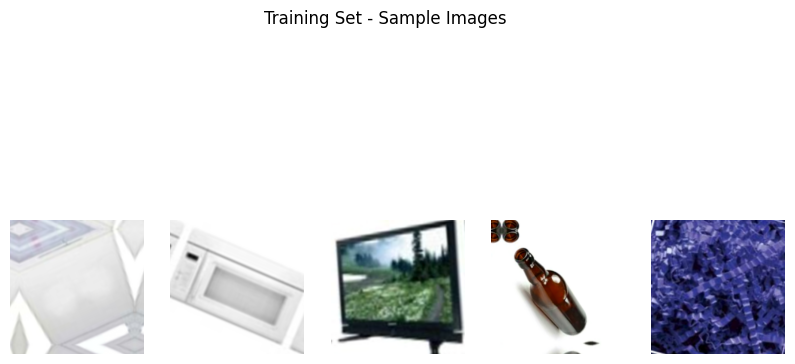

2025-05-19 01:06:54.548074: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 19268224 bytes after encountering the first element of size 19268224 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


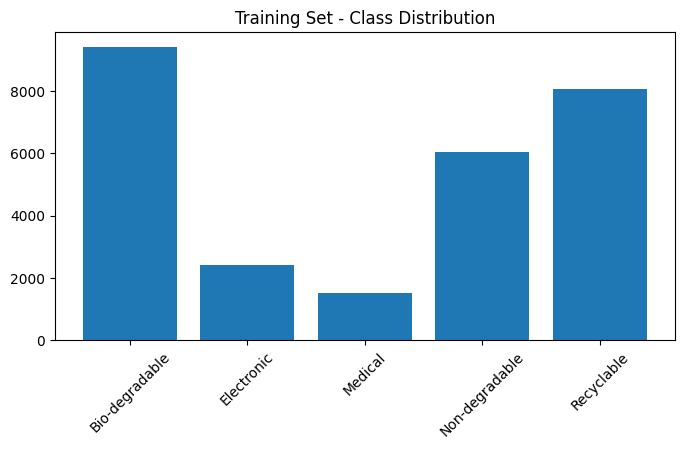


Class Counts:
Bio-degradable: 9415 samples
Electronic: 2406 samples
Medical: 1508 samples
Non-degradable: 6031 samples
Recyclable: 8062 samples

Validation Set - Pixel Value Check:
Min value: 0.0000
Max value: 1.0000
Mean value: 0.5686


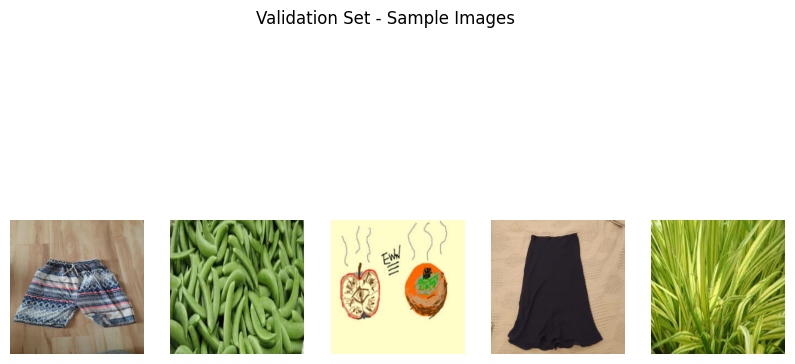

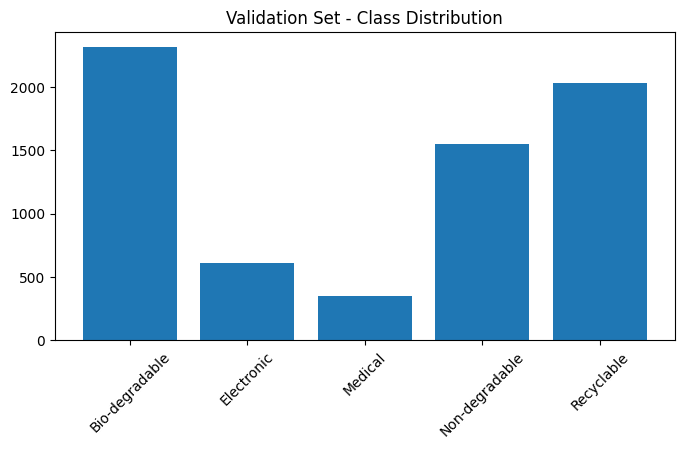


Class Counts:
Bio-degradable: 2317 samples
Electronic: 610 samples
Medical: 348 samples
Non-degradable: 1551 samples
Recyclable: 2029 samples

Test Set - Pixel Value Check:
Min value: 0.0000
Max value: 1.0000
Mean value: 0.6878


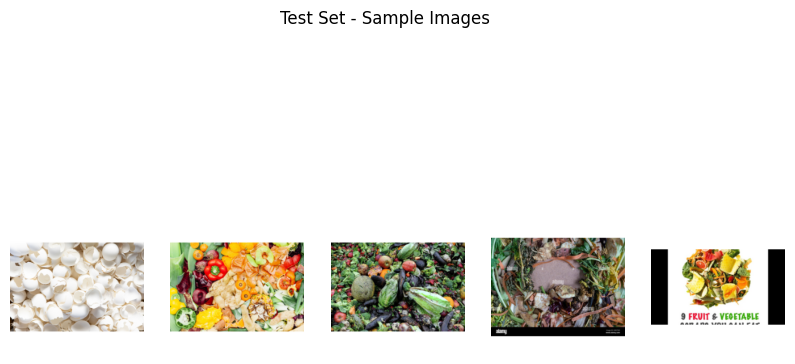

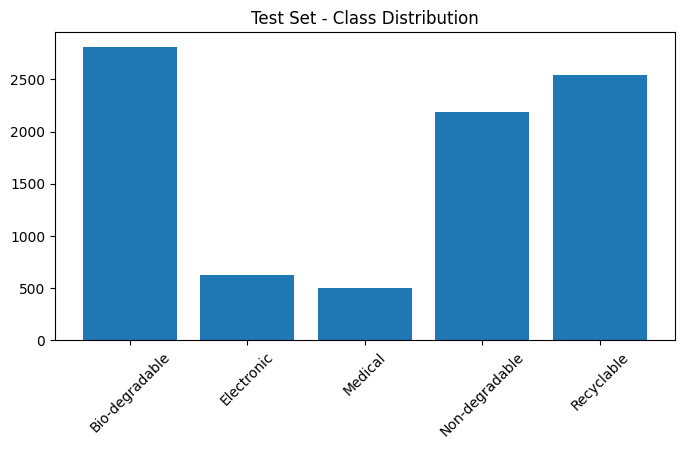


Class Counts:
Bio-degradable: 2812 samples
Electronic: 628 samples
Medical: 499 samples
Non-degradable: 2188 samples
Recyclable: 2546 samples


In [10]:
def verify_and_visualize(dataset, title):
    # Check normalization
    for images, _ in dataset.take(1):
        print(f"\n{title} - Pixel Value Check:")
        print(f"Min value: {tf.reduce_min(images):.4f}")
        print(f"Max value: {tf.reduce_max(images):.4f}")
        print(f"Mean value: {tf.reduce_mean(images):.4f}")
        
        # Visualize sample images
        plt.figure(figsize=(10, 5))
        for i in range(5):
            plt.subplot(1, 5, i+1)
            plt.imshow(images[i].numpy())
            plt.axis('off')
        plt.suptitle(f"{title} - Sample Images", y=1.05)
        plt.show()
    
    # Check class distribution
    class_counts = {name: 0 for name in class_names}
    for _, labels in dataset:
        for label in labels:
            class_counts[class_names[tf.argmax(label).numpy()]] += 1
    
    plt.figure(figsize=(8, 4))
    plt.bar(class_counts.keys(), class_counts.values())
    plt.title(f"{title} - Class Distribution")
    plt.xticks(rotation=45)
    plt.show()
    
    print("\nClass Counts:")
    for class_name, count in class_counts.items():
        print(f"{class_name}: {count} samples")

# Verify all datasets
verify_and_visualize(train_ds, "Training Set")
verify_and_visualize(val_ds, "Validation Set")
verify_and_visualize(test_ds, "Test Set")

2025-05-19 01:15:00.050200: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 19268224 bytes after encountering the first element of size 19268224 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-05-19 01:19:49.191423: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


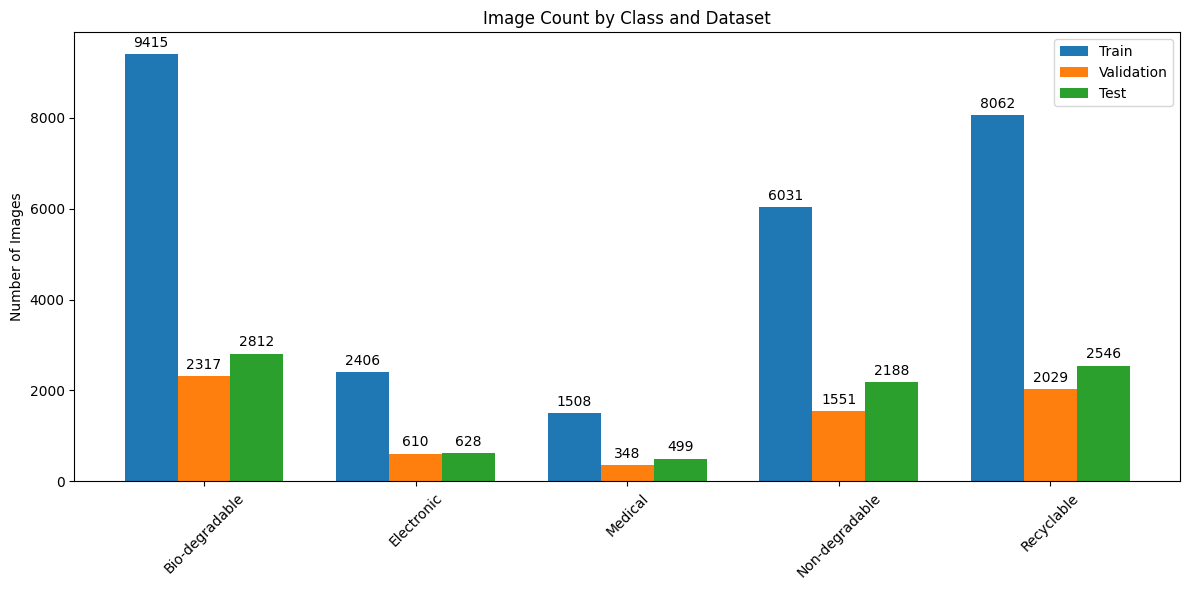

In [11]:
# Assuming you have these datasets from your previous code
# train_dataset, val_dataset, test_dataset

def get_class_counts(dataset):
    """Count number of samples per class in a dataset"""
    counts = {class_name: 0 for class_name in class_names}
    for _, labels in dataset:
        # Convert one-hot encoded labels back to class indices
        class_indices = np.argmax(labels.numpy(), axis=1)
        for idx in class_indices:
            counts[class_names[idx]] += 1
    return counts

# Get counts for each dataset
train_counts = get_class_counts(train_dataset)
val_counts = get_class_counts(val_dataset)
test_counts = get_class_counts(test_dataset)

# Prepare data for plotting
classes = class_names
train_values = [train_counts[cls] for cls in classes]
val_values = [val_counts[cls] for cls in classes]
test_values = [test_counts[cls] for cls in classes]

x = np.arange(len(classes))  # the label locations
width = 0.25  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars for each dataset
rects1 = ax.bar(x - width, train_values, width, label='Train')
rects2 = ax.bar(x, val_values, width, label='Validation')
rects3 = ax.bar(x + width, test_values, width, label='Test')

# Add some text for labels, title and custom x-axis tick labels
ax.set_ylabel('Number of Images')
ax.set_title('Image Count by Class and Dataset')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45)
ax.legend()

# Add counts on top of bars
def autolabel(rects):
    """Attach a text label above each bar showing its height"""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

fig.tight_layout()
plt.show()

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_model(input_shape=(224,224,3), num_classes=5):
    model = Sequential([
        # Input layer (shape after preprocessing)
        layers.Input(shape=input_shape),
        
        # First Conv Block
        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),
        
        # Second Conv Block  
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),
        
        # Third Conv Block
        Conv2D(128, (3,3), activation='relu', padding='same'), 
        MaxPooling2D((2,2)),
        
        # Classification Head
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

model = build_model()
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,784,901 (98.36 MB)

 Trainable params: 25,784,901 (98.36 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', save_best_only=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

# 2. Optional: Save weights separately (extra backup)
# model.save_weights('waste_classifier_weights.h5')

Epoch 1/10


2025-05-19 01:20:09.649408: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 19268224 bytes after encountering the first element of size 19268224 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


857/857 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5637 - loss: 1.1289

857/857 ━━━━━━━━━━━━━━━━━━━━ 1362s 2s/step - accuracy: 0.5638 - loss: 1.1287 - val_accuracy: 0.6738 - val_loss: 0.8035
Epoch 2/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6762 - loss: 0.8308

857/857 ━━━━━━━━━━━━━━━━━━━━ 1351s 2s/step - accuracy: 0.6762 - loss: 0.8308 - val_accuracy: 0.6947 - val_loss: 0.7644
Epoch 3/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6945 - loss: 0.7806

...

857/857 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7289 - loss: 0.6986

857/857 ━━━━━━━━━━━━━━━━━━━━ 1406s 2s/step - accuracy: 0.7289 - loss: 0.6986 - val_accuracy: 0.7546 - val_loss: 0.6290
Epoch 7/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 1249s 1s/step - accuracy: 0.7425 - loss: 0.6774 - val_accuracy: 0.7519 - val_loss: 0.6363
Epoch 8/10


2025-05-19 04:00:06.906313: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 19268224 bytes after encountering the first element of size 19268224 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


857/857 ━━━━━━━━━━━━━━━━━━━━ 15403s 18s/step - accuracy: 0.7416 - loss: 0.6823 - val_accuracy: 0.7411 - val_loss: 0.6624
Epoch 9/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 1698s 2s/step - accuracy: 0.7473 - loss: 0.6686 - val_accuracy: 0.7491 - val_loss: 0.6663
Epoch 10/10
857/857 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7547 - loss: 0.6476

857/857 ━━━━━━━━━━━━━━━━━━━━ 1570s 2s/step - accuracy: 0.7547 - loss: 0.6476 - val_accuracy: 0.7581 - val_loss: 0.6282


In [15]:
# 1. Save the entire model
model.save('waste_classifier_full.h5')

print("Model saved successfully!")

Model saved successfully!


272/272 ━━━━━━━━━━━━━━━━━━━━ 101s 370ms/step - accuracy: 0.7684 - loss: 0.6170
Test Accuracy: 72.44%


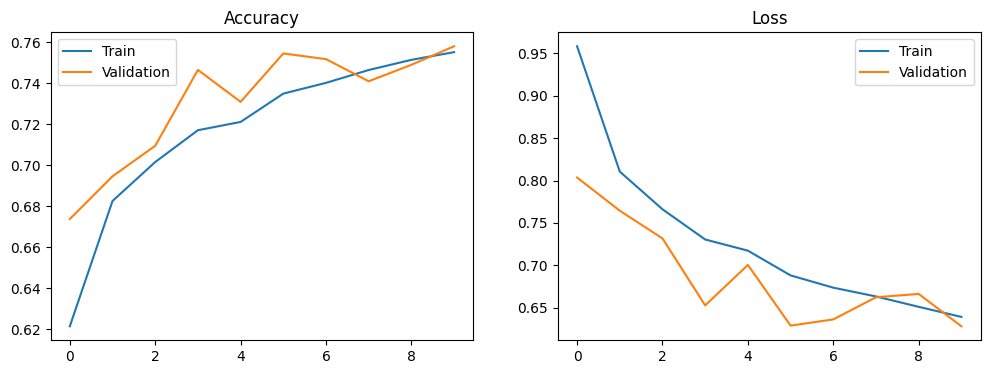

In [16]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.2%}")

# Plot training history
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train') 
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()
plt.show()

In [2]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model
model = load_model('waste_classifier_full.h5')


# Load VGG16 base model (pretrained on ImageNet)
base_model = VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3),
    pooling='avg'  # GlobalAveragePooling at the end
)

# Freeze all layers in the base model
base_model.trainable = False

# Build custom classification head
model = Sequential([
    base_model,
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(5, activation='softmax')  # 5 classes for waste
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

2025-05-20 15:15:58.811488: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-20 15:15:58.825648: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-20 15:15:58.900734: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-20 15:15:58.952892: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747734359.011803    3005 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747734359.02

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 512)            │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,325 (56.64 MB)

 Trainable params: 133,125 (520.02 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

In [3]:
# Define callbacks
callbacks = [
    EarlyStopping(patience=5, monitor='val_loss', restore_best_weights=True),
    ModelCheckpoint('vgg16_waste_best.h5', save_best_only=True)
]

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

NameError: name 'train_ds' is not defined

In [ ]:
# Unfreeze last 4 blocks of VGG16 (while keeping early layers frozen)
base_model.trainable = True
for layer in base_model.layers[:15]:  # Freeze first 15 layers (Block1-4)
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),  # 10x smaller than initial
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tune for fewer epochs
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    initial_epoch=history.epoch[-1],  # Continue from last epoch
    callbacks=callbacks
)

In [ ]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc:.2%}")

# Save the final model
model.save('vgg16_waste_final.h5')
print("Model saved as 'vgg16_waste_final.h5'")

# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'] + history_fine.history['accuracy'])
plt.plot(history.history['val_accuracy'] + history_fine.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Val'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'] + history_fine.history['loss'])
plt.plot(history.history['val_loss'] + history_fine.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Val'])
plt.show()